# GOES ABI Full Disk - one band (10.3 um)

The most general view first: the clean infrared window at 10.3 um over the whole disk, then the same band zoomed to a box with a colour bar. It measures brightness temperature, so it works day and night.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/),
then point `DATA_DIR` at the folder they landed in. Nothing is downloaded here.

**Steps:** your files -> the whole scan -> your box -> that box.

The plotting is plain matplotlib and cartopy, written out where it happens, so
change the colours, the projection or anything else right there.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml

sys.path.insert(0, "..")
import goestools as gt

CONFIG = yaml.safe_load(open("../config.yml"))
STYLE = CONFIG["style"]          # colours, widths, figure size


## 1. Your files

In [2]:
DATA_DIR = Path("..") / CONFIG["data"]["full_disk"]
CHANNELS = ["C13"]                # 10.3 um clean infrared window

files = sorted(glob.glob(str(DATA_DIR / "*.nc")))
print(f"{DATA_DIR}: {len(files)} file(s)")
for name in files:
    print("   ", Path(name).name)

paths = gt.find_channels(files, CHANNELS)    # raises if one is missing


../data/full_disk: 10 file(s)
    OR_ABI-L1b-RadF-M6C01_G18_s20232761900206_e20232761909514_c20232761909554.nc
    OR_ABI-L1b-RadF-M6C02_G18_s20232761900206_e20232761909514_c20232761909546.nc
    OR_ABI-L1b-RadF-M6C03_G18_s20232761900206_e20232761909514_c20232761909559.nc
    OR_ABI-L1b-RadF-M6C07_G18_s20232761900206_e20232761909526_c20232761909567.nc
    OR_ABI-L1b-RadF-M6C09_G18_s20232761900206_e20232761909520_c20232761909561.nc
    OR_ABI-L1b-RadF-M6C10_G18_s20232761900206_e20232761909526_c20232761909548.nc
    OR_ABI-L1b-RadF-M6C11_G18_s20232761900206_e20232761909514_c20232761909558.nc
    OR_ABI-L1b-RadF-M6C13_G18_s20232761900206_e20232761909526_c20232761909572.nc
    OR_ABI-L1b-RadF-M6C14_G18_s20232761900206_e20232761909514_c20232761909569.nc
    OR_ABI-L1b-RadF-M6C15_G18_s20232761900206_e20232761909520_c20232761909555.nc


## 2. The whole scan

A whole scan really is a disk, so it is drawn in the satellite's own
Geostationary projection. `stride` takes every n-th pixel to keep it quick.

<Subset G18 C13 bt (678, 678) at 2023-10-03 19:00:20.655517>
colour limits: 207.8 to 305.1 K


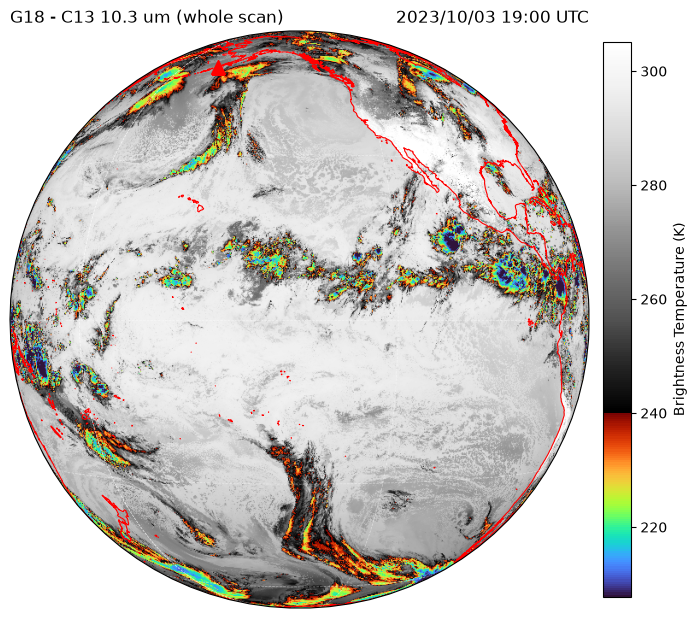

In [3]:
p = CONFIG["products"]["band"]
whole = gt.read_subset(paths["C13"], quantity="bt", stride=STYLE["overview_stride"])
print(whole)

# COLOUR SCALE ------------------------------------------------------------
# vmin / vmax in config.yml are null, so the limits come from the data. Put a
# number there, or here, to fix either end -- do that when you want two scans
# on the same scale.
vmin, vmax = gt.data_limits(whole.bt, p["vmin"], p["vmax"])
print(f"colour limits: {vmin:.1f} to {vmax:.1f} K")

# Everything colder than enhance_below is picked out in colour, the way
# forecasters enhance deep convection and ash. Set it to null to switch off.
if p["enhance_below"] is not None:
    cmap, norm = gt.enhanced_scale(vmin, vmax, p["enhance_below"],
                                   cold_cmap=p["enhance_cmap"])
    scale = dict(cmap=cmap, norm=norm)
else:
    scale = dict(cmap=p["cmap"], vmin=vmin, vmax=vmax)

crs = gt.cartopy_crs(whole.gs)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 1, 1, projection=crs)

img = ax.imshow(whole.bt, origin="upper", extent=whole.extent, transform=crs,
                **scale)

ax.coastlines(resolution="50m", color=STYLE["coast_colour"],
              linewidth=STYLE["coast_width"])
ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
             linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
if STYLE["marker_lon"] is not None:
    ax.plot(STYLE["marker_lon"], STYLE["marker_lat"], "^",
            color=STYLE["marker_colour"], ms=STYLE["marker_size"],
            transform=ccrs.PlateCarree())

ax.set_title("G18 - C13 10.3 um (whole scan)", loc="left")
ax.set_title(f"{whole.time:%Y/%m/%d %H:%M} UTC", loc="right")
plt.colorbar(img, ax=ax, pad=0.02, shrink=0.8, label=p["colorbar_label"])
plt.show()


## 3. Your box

In [4]:
# YOUR BOX -- four numbers, decimal degrees. There is no preset.
#     LON_MIN, LON_MAX, LAT_MIN, LAT_MAX      (west, east, south, north)
# Set BOX = None to skip the crop.
BOX = (-169.0, -159.0, 52.5, 57.0)

print("box:", BOX)


box: (-169.0, -159.0, 52.5, 57.0)


## 4. Your box

Only the pixels inside the box are read, so this is quick even from a Full
Disk. `pcolormesh` puts each pixel where the satellite saw it, using the
corner coordinates -- nothing is resampled onto a new grid.

<Subset G18 C13 bt (139, 359) at 2023-10-03 19:00:20.655517>


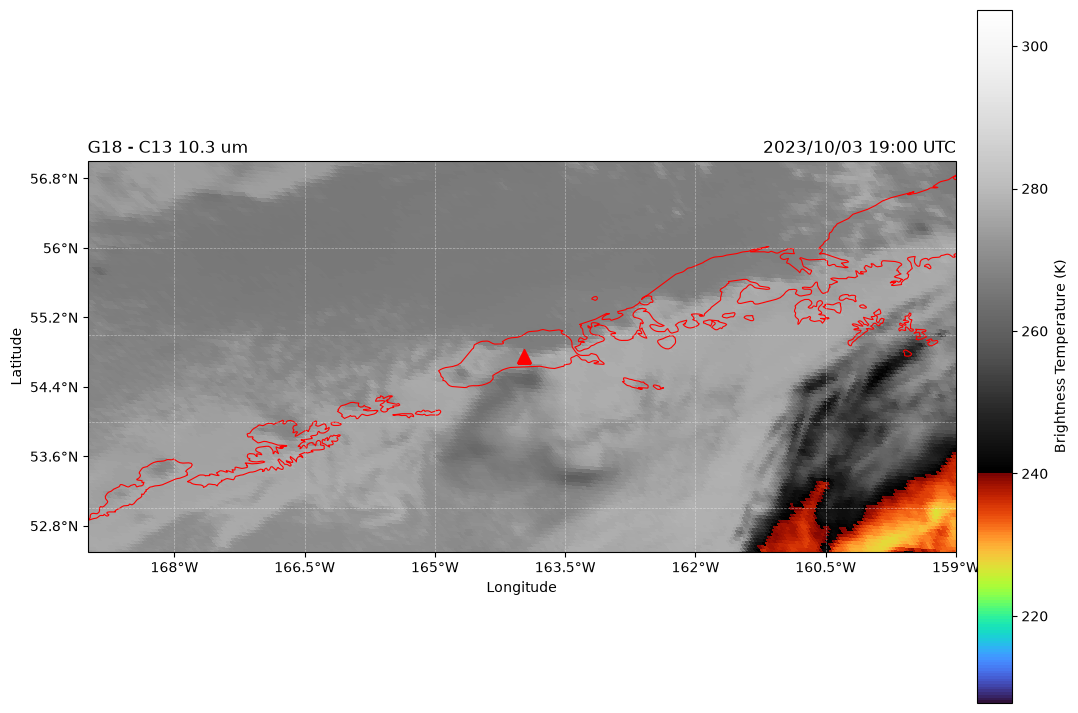

In [5]:
if BOX is None:
    print("No box set.")
else:
    sub = gt.read_subset(paths["C13"], *BOX, quantity="bt")
    print(sub)

    fig = plt.figure(figsize=(STYLE["figure_width"], 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Same scale as above, so the box and the whole scan are comparable. Drop
    # the `scale` below and build a new one from sub.bt to stretch to the box.
    img = ax.pcolormesh(sub.lon_corners, sub.lat_corners, sub.bt,
                        transform=ccrs.PlateCarree(), **scale)

    ax.coastlines(resolution=STYLE["coast_resolution"],
                  color=STYLE["coast_colour"], linewidth=STYLE["coast_width"])
    ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
                 linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
    gt.degree_ticks(ax, *BOX)
    if STYLE["marker_lon"] is not None:
        ax.plot(STYLE["marker_lon"], STYLE["marker_lat"], "^",
                color=STYLE["marker_colour"], ms=STYLE["marker_size"],
                transform=ccrs.PlateCarree())

    ax.set_extent(BOX, crs=ccrs.PlateCarree())
    ax.set_title("G18 - C13 10.3 um", loc="left")
    ax.set_title(f"{sub.time:%Y/%m/%d %H:%M} UTC", loc="right")
    plt.colorbar(img, ax=ax, pad=0.02, label=p["colorbar_label"])
    plt.show()


## Notes

* `quantity="bt"` is brightness temperature in kelvin, worked out from the
  radiance with the calibration in the file. Use `"reflectance"` for the
  visible channels or `"radiance"` for the raw values.
* `vmin` / `vmax` and the colour map live in `config.yml`.
* Any other channel works the same way: change `CHANNELS`.